In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from shapely.geometry import Polygon, LineString, MultiLineString
from dataclasses import dataclass, asdict

In [2]:
@dataclass
class Swath:
    start: tuple[float, float]
    end: tuple[float, float]

In [9]:
import json

# 1. Load the user's data file
with open('canvas.json', 'r') as file:
    user_data = json.load(file)

# 2. Extract the variables
user_brush = user_data['brush_diameter']
user_exterior = user_data['exterior_coordinates']
user_holes = user_data['hole_coordinates']

print(f"Loaded canvas with {len(user_exterior)} exterior points and {len(user_holes)} holes.")

Loaded canvas with 4 exterior points and 1 holes.


In [10]:
# Updated function to accept holes from the user
def generate_paint_lines(exterior, holes, brush_diameter):
    brush_radius = brush_diameter / 2.0
    # Create polygon with exterior and holes
    canvas = Polygon(exterior, holes) 
    safe_zone = canvas.buffer(-brush_radius)
    
    # ... (The rest of the sweep-line logic remains exactly the same!)
    minx, miny, maxx, maxy = safe_zone.bounds
    swaths = []
    y_coords = np.arange(miny + brush_radius, maxy, brush_diameter)
    
    for y in y_coords:
        sweep_line = LineString([(minx - 1, y), (maxx + 1, y)])
        clipped_lines = sweep_line.intersection(safe_zone)
        
        if clipped_lines.is_empty:
            continue
            
        lines_to_process = [clipped_lines] if isinstance(clipped_lines, LineString) else list(clipped_lines.geoms)
        
        for line in lines_to_process:
            coords = list(line.coords)
            swaths.append(Swath(start=coords[0], end=coords[-1]))
            
    return canvas, safe_zone, swaths

# Run the engine with the user's dynamic data!
canvas_poly, safe_poly, paint_strokes = generate_paint_lines(
    user_exterior, 
    user_holes, 
    user_brush
)

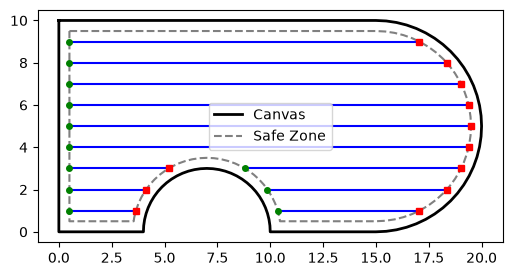

In [6]:
fig, ax = plt.subplots(figsize=(6, 6))

# Plot canvas and safe zone
ax.plot(*canvas_poly.exterior.xy, color='black', linewidth=2, label='Canvas')
ax.plot(*safe_poly.exterior.xy, color='gray', linestyle='--', label='Safe Zone')

# Plot strokes
for s in paint_strokes:
    ax.plot([s.start[0], s.end[0]], [s.start[1], s.end[1]], color='blue')
    ax.plot(s.start[0], s.start[1], 'go', markersize=4) # Green Start
    ax.plot(s.end[0], s.end[1], 'rs', markersize=4)   # Red End

ax.set_aspect('equal')
plt.legend()
plt.show()

In [7]:
# Convert dataclass objects to standard dictionaries for JSON export
export_data = [asdict(swath) for swath in paint_strokes]

with open('generated_swaths.json', 'w') as f:
    json.dump(export_data, f, indent=4)
    
print(f"Exported {len(export_data)} paint strokes to generated_swaths.json!")

Exported 12 paint strokes to generated_swaths.json!
